# Analisis Sentimen Review Shopee — Google Play Store

In [1]:
!pip install -q Sastrawi google-play-scraper tqdm scikit-learn tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.6 MB/s eta 0:00:00


## 1. Scraping Data

In [2]:
import pandas as pd
import time
from google_play_scraper import Sort, reviews

app_id = "com.shopee.id"
all_reviews = []
token = None
TARGET = 15000

while len(all_reviews) < TARGET:
    batch, token = reviews(
        app_id, lang="id", country="id",
        sort=Sort.NEWEST, count=200,
        continuation_token=token
    )
    all_reviews.extend(batch)
    print("Total:", len(all_reviews))
    if token is None:
        break
    time.sleep(1)

df_raw = pd.DataFrame(all_reviews)[["content"]]
df_raw = df_raw.dropna().drop_duplicates().head(TARGET)
df_raw.to_csv("raw_data.csv", index=False)
print("Final data:", len(df_raw))

Total: 200
Total: 400
Total: 600
Total: 800
Total: 1000
Total: 1200
Total: 1400
Total: 1600
Total: 1800
Total: 2000
Total: 2200
Total: 2400
Total: 2600
Total: 2800
Total: 3000
Total: 3200
Total: 3400
Total: 3600
Total: 3800
Total: 4000
Total: 4200
Total: 4400
Total: 4600
Total: 4800
Total: 5000
Total: 5200
Total: 5400
Total: 5600
Total: 5800
Total: 6000
Total: 6200
Total: 6400
Total: 6600
Total: 6800
Total: 7000
Total: 7200
Total: 7400
Total: 7600
Total: 7800
Total: 8000
Total: 8200
Total: 8400
Total: 8600
Total: 8800
Total: 9000
Total: 9200
Total: 9400
Total: 9600
Total: 9800
Total: 10000
Total: 10200
Total: 10400
Total: 10600
Total: 10800
Total: 11000
Total: 11200
Total: 11400
Total: 11600
Total: 11800
Total: 12000
Total: 12200
Total: 12400
Total: 12600
Total: 12800
Total: 13000
Total: 13200
Total: 13400
Total: 13600
Total: 13800
Total: 14000
Total: 14200
Total: 14400
Total: 14600
Total: 14800
Total: 15000
Final data: 12135


## 2. Preprocessing & Pelabelan

Label berbasis **InSet Lexicon** (Bahasa Indonesia):
- Kata positif > kata negatif → **Positif (1)**
- Kata negatif > kata positif → **Negatif (0)**
- Tie → di-drop (ambigu)

In [3]:
import re
import requests
import pandas as pd
from tqdm.auto import tqdm
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

tqdm.pandas()

df = pd.read_csv("raw_data.csv")

stemmer = StemmerFactory().create_stemmer()

stop_words = {
    "yang","dan","di","ke","dari","ini","itu","untuk",
    "dengan","karena","ada","saya","aku","kamu","nya",
    "juga","sudah","bisa","tidak","lebih","jadi","kalau"
}

pos_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
neg_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive = set(w.split("\t")[0] for w in requests.get(pos_url).text.split("\n") if w)
negative = set(w.split("\t")[0] for w in requests.get(neg_url).text.split("\n") if w)

positive.update(["bagus","mantap","cepat","membantu","baik","puas","keren","aman"])
negative.update(["lama","rusak","error","lemot","kecewa","buruk","gagal","lambat"])

positive = set(stemmer.stem(w) for w in positive)
negative = set(stemmer.stem(w) for w in negative)

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [stemmer.stem(w) for w in tokens]
    return tokens

def label_text(tokens):
    pos = sum(1 for w in tokens if w in positive)
    neg = sum(1 for w in tokens if w in negative)
    if pos > neg:
        return 1
    elif neg > pos:
        return 0
    else:
        return None  # tie → drop

df["tokens"] = df["content"].progress_apply(preprocess)
df["label"]  = df["tokens"].progress_apply(label_text)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
df["clean"] = df["tokens"].apply(lambda x: " ".join(x))
df = df[["clean", "label"]]
df.to_csv("dataset.csv", index=False)

print("Distribusi label:")
print(df["label"].value_counts())
print(f"Total data: {len(df):,}")

  0%|          | 0/12135 [00:00<?, ?it/s]

  0%|          | 0/12135 [00:00<?, ?it/s]

Distribusi label:
label
0    4080
1    4000
Name: count, dtype: int64
Total data: 8,080


## 3. Balancing Data

Distribusi setelah balancing:
label
1    4000
0    4000
Name: count, dtype: int64
Total: 8,000


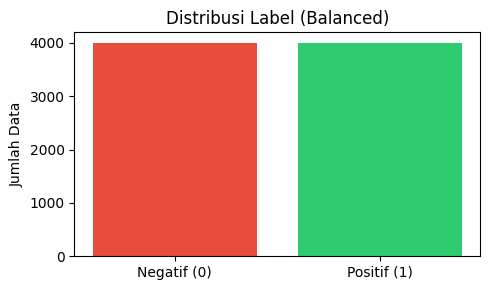

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")

n = df["label"].value_counts().min()
df_bal = pd.concat([
    df[df.label == 1].sample(n, random_state=42),
    df[df.label == 0].sample(n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi setelah balancing:")
print(df_bal["label"].value_counts())
print(f"Total: {len(df_bal):,}")

plt.figure(figsize=(5, 3))
plt.bar(["Negatif (0)", "Positif (1)"],
        df_bal["label"].value_counts().sort_index().values,
        color=["#e74c3c", "#2ecc71"])
plt.title("Distribusi Label (Balanced)")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.savefig("distribusi_label.png", dpi=100)
plt.show()

## 4. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = df_bal["clean"]
y = df_bal["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 6,400 | Test: 1,600


## 5. Skema 1 — TF-IDF + SVM (LinearSVC)

ML klasik sebagai baseline. TF-IDF unigram+bigram, LinearSVC.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
import joblib

pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=30000, sublinear_tf=True)),
    ("clf",   LinearSVC(C=1.0, max_iter=2000))
])

pipe_svm.fit(X_train, y_train)

acc_train_s1 = accuracy_score(y_train, pipe_svm.predict(X_train))
acc_test_s1  = accuracy_score(y_test,  pipe_svm.predict(X_test))

print(f"[Skema 1 — SVM] Train: {acc_train_s1*100:.2f}% | Test: {acc_test_s1*100:.2f}%")
print()
print(classification_report(y_test, pipe_svm.predict(X_test),
      target_names=["Negatif", "Positif"]))

joblib.dump(pipe_svm, "model_svm.pkl")

[Skema 1 — SVM] Train: 100.00% | Test: 95.69%

              precision    recall  f1-score   support

     Negatif       0.94      0.98      0.96       800
     Positif       0.98      0.94      0.96       800

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



['model_svm.pkl']

## 6. Persiapan Deep Learning (Shared)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

VOCAB_SIZE = 15000
MAX_LEN    = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def encode(X):
    seqs = tokenizer.texts_to_sequences(X)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post")

X_train_pad = encode(X_train)
X_test_pad  = encode(X_test)

print(f"X_train: {X_train_pad.shape} | X_test: {X_test_pad.shape}")

X_train: (6400, 100) | X_test: (1600, 100)


## 7. Skema 2 — Bi-LSTM + Embedding

Deep learning dengan LSTM dua arah untuk menangkap konteks kalimat.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

model_lstm = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model_lstm.summary()

es = EarlyStopping(patience=2, restore_best_weights=True, monitor="val_accuracy")

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=64,
    validation_split=0.15,
    callbacks=[es], verbose=1
)

y_pred_lstm  = (model_lstm.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_train_s2 = history_lstm.history["accuracy"][-1]
acc_test_s2  = accuracy_score(y_test, y_pred_lstm)

print(f"\n[Skema 2 — Bi-LSTM] Train: {acc_train_s2*100:.2f}% | Test: {acc_test_s2*100:.2f}%")
print()
print(classification_report(y_test, y_pred_lstm, target_names=["Negatif", "Positif"]))

model_lstm.save("model_lstm.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7502 - loss: 0.4772 - val_accuracy: 0.9219 - val_loss: 0.2262
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9592 - loss: 0.1160 - val_accuracy: 0.9354 - val_loss: 0.1817
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9917 - loss: 0.0272 - val_accuracy: 0.9521 - val_loss: 0.1641
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9934 - loss: 0.0219 - val_accuracy: 0.9417 - val_loss: 0.2560
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.9323 - val_loss: 0.2894
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

[Skema 2 — Bi-LSTM] Train: 99.60% | Test: 95.56%



              precision    recall  f1-score   support

     Negatif       0.96      0.95      0.96       800
     Positif       0.95      0.96      0.96       800

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



## 8. Skema 3 — CNN 1D + Embedding

CNN untuk teks: lebih cepat dari LSTM, efektif menangkap pola lokal (n-gram).

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, GlobalMaxPooling1D,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

model_cnn = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    Conv1D(128, 5, activation="relu"),
    BatchNormalization(),
    Conv1D(64, 3, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_cnn.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model_cnn.summary()

es = EarlyStopping(patience=2, restore_best_weights=True, monitor="val_accuracy")

history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=64,
    validation_split=0.15,
    callbacks=[es], verbose=1
)

y_pred_cnn   = (model_cnn.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_train_s3 = history_cnn.history["accuracy"][-1]
acc_test_s3  = accuracy_score(y_test, y_pred_cnn)

print(f"\n[Skema 3 — CNN 1D] Train: {acc_train_s3*100:.2f}% | Test: {acc_test_s3*100:.2f}%")
print()
print(classification_report(y_test, y_pred_cnn, target_names=["Negatif", "Positif"]))

model_cnn.save("model_cnn.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6708 - loss: 0.5965 - val_accuracy: 0.8198 - val_loss: 0.6503
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9072 - loss: 0.2446 - val_accuracy: 0.9083 - val_loss: 0.5583
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9702 - loss: 0.0930 - val_accuracy: 0.9021 - val_loss: 0.4700
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9824 - loss: 0.0605 - val_accuracy: 0.9302 - val_loss: 0.3236
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9888 - loss: 0.0304 - val_accuracy: 0.9229 - val_loss: 0.2365
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9904 - loss: 0.0275 - val_accuracy: 0.9260 - val_loss: 0.2270
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step



[Skema 3 — CNN 1D] Train: 99.04% | Test: 91.88%

              precision    recall  f1-score   support

     Negatif       0.88      0.96      0.92       800
     Positif       0.96      0.87      0.91       800

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



## 9. Perbandingan Hasil 3 Skema

                Skema  Train Acc (%)  Test Acc (%)
Skema 1: TF-IDF + SVM         100.00         95.69
     Skema 2: Bi-LSTM          99.60         95.56
      Skema 3: CNN 1D          99.04         91.88


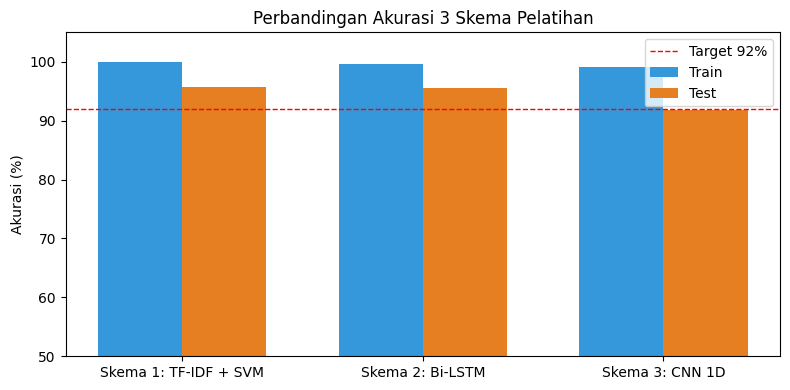


Model terbaik: Skema 1: TF-IDF + SVM (Test Acc: 95.69%)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Skema"        : ["Skema 1: TF-IDF + SVM", "Skema 2: Bi-LSTM", "Skema 3: CNN 1D"],
    "Train Acc (%)": [round(acc_train_s1*100, 2), round(acc_train_s2*100, 2), round(acc_train_s3*100, 2)],
    "Test Acc (%)" : [round(acc_test_s1*100,  2), round(acc_test_s2*100,  2), round(acc_test_s3*100,  2)],
})

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(results))
w = 0.35
ax.bar([i - w/2 for i in x], results["Train Acc (%)"], w, label="Train", color="#3498db")
ax.bar([i + w/2 for i in x], results["Test Acc (%)"],  w, label="Test",  color="#e67e22")
ax.axhline(92, color="red", linestyle="--", linewidth=1, label="Target 92%")
ax.set_xticks(list(x))
ax.set_xticklabels(results["Skema"])
ax.set_ylabel("Akurasi (%)")
ax.set_title("Perbandingan Akurasi 3 Skema Pelatihan")
ax.legend()
ax.set_ylim(50, 105)
plt.tight_layout()
plt.savefig("perbandingan_akurasi.png", dpi=100)
plt.show()

best = results.loc[results["Test Acc (%)"].idxmax()]
print(f"\nModel terbaik: {best['Skema']} (Test Acc: {best['Test Acc (%)']:.2f}%)")

## 10. Inference — Fungsi Prediksi

Menggunakan **model terbaik** (pilih Bi-LSTM atau CNN 1D berdasarkan hasil di atas).  
Fungsi ini melakukan preprocessing yang sama persis dengan saat training.

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

LABEL_MAP = {0: "Negatif", 1: "Positif"}
EMOJI_MAP  = {"Negatif": "😞", "Positif": "😊"}

# Ganti model_cnn → model_lstm jika Bi-LSTM hasilnya lebih baik
best_model = model_cnn

def predict_sentiment(text):
    tokens = preprocess(text)
    clean  = " ".join(tokens)
    seq    = tokenizer.texts_to_sequences([clean])
    pad    = pad_sequences(seq, maxlen=MAX_LEN, padding="post")
    prob   = float(best_model.predict(pad, verbose=0)[0][0])
    label  = LABEL_MAP[int(prob >= 0.5)]
    return {
        "text"      : text,
        "label"     : label,
        "confidence": f"{max(prob, 1-prob)*100:.1f}%"
    }

samples = [
    "barang cepat sampai dan bagus banget, puas!",
    "pengiriman lama sekali dan barang rusak saat tiba",
    "aplikasi membantu sekali untuk belanja sehari-hari",
    "sering error dan mengecewakan, kapok belanja di sini",
    "shopee mantap, banyak promo dan aman",
]

print("=" * 60)
for s in samples:
    r = predict_sentiment(s)
    print(f"{EMOJI_MAP[r['label']]} {r['label']:8s} ({r['confidence']}) | {r['text']}")
print("=" * 60)

😊 Positif  (90.2%) | barang cepat sampai dan bagus banget, puas!
😞 Negatif  (84.0%) | pengiriman lama sekali dan barang rusak saat tiba
😞 Negatif  (80.0%) | aplikasi membantu sekali untuk belanja sehari-hari
😞 Negatif  (84.7%) | sering error dan mengecewakan, kapok belanja di sini
😊 Positif  (85.4%) | shopee mantap, banyak promo dan aman


## 11. Ringkasan Proyek

In [12]:
print("=" * 65)
print("RINGKASAN PROYEK ANALISIS SENTIMEN")
print("=" * 65)
print(f"Topik      : Review Aplikasi Shopee — Google Play Store")
print(f"Total Data : {len(df_bal):,} (balanced, 2 kelas)")
print(f"Kelas      : Negatif (0) · Positif (1)")
print(f"Pelabelan  : InSet Lexicon (Bahasa Indonesia)")
print(f"Split      : 80% Train / 20% Test (stratified)")
print()
print(f"Skema 1 — TF-IDF + SVM   : Train {acc_train_s1*100:.2f}%  |  Test {acc_test_s1*100:.2f}%")
print(f"Skema 2 — Bi-LSTM         : Train {acc_train_s2*100:.2f}%  |  Test {acc_test_s2*100:.2f}%")
print(f"Skema 3 — CNN 1D          : Train {acc_train_s3*100:.2f}%  |  Test {acc_test_s3*100:.2f}%")
print("=" * 65)

RINGKASAN PROYEK ANALISIS SENTIMEN
Topik      : Review Aplikasi Shopee — Google Play Store
Total Data : 8,000 (balanced, 2 kelas)
Kelas      : Negatif (0) · Positif (1)
Pelabelan  : InSet Lexicon (Bahasa Indonesia)
Split      : 80% Train / 20% Test (stratified)

Skema 1 — TF-IDF + SVM   : Train 100.00%  |  Test 95.69%
Skema 2 — Bi-LSTM         : Train 99.60%  |  Test 95.56%
Skema 3 — CNN 1D          : Train 99.04%  |  Test 91.88%
